### Task 1:

Loading MNIST...
Applying PCA to 2D for visualization...


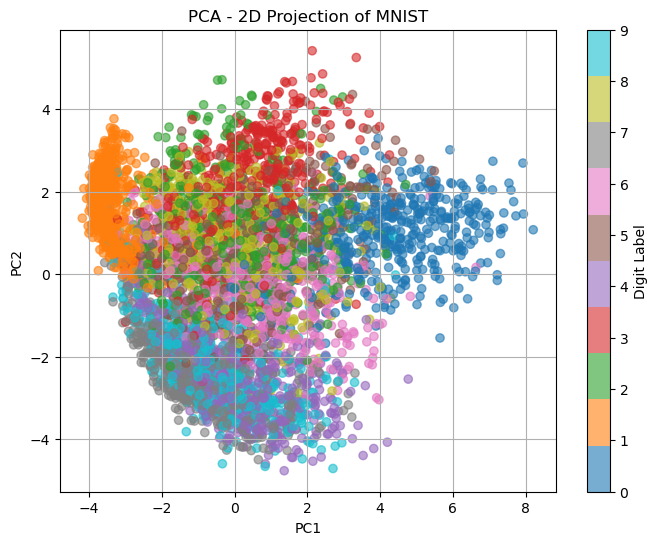

Applying PCA to 32D for reconstruction...

 MSE (32D PCA Reconstruction): 0.01684
 Explained Variance by 32D: 74.91%
 Avg MSE per image: 0.01684


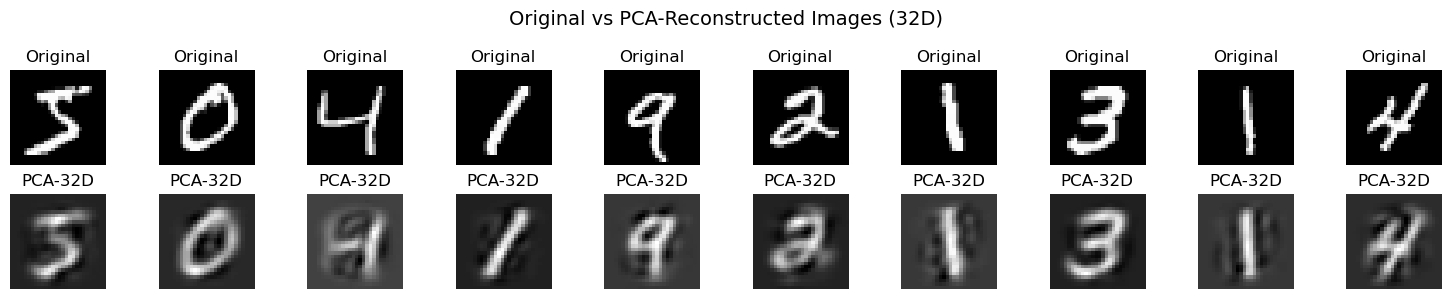

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# Fetching and preprocessing the MNIST dataset.

print("Loading MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data.astype(np.float32) / 255.0
y = mnist.target.astype(int)

# We will use a larger but still efficient subset
X_sample = X[:5000]
y_sample = y[:5000]

# Task 1a: PCA to 2D for visualization

print("Applying PCA to 2D for visualization...")
pca_2d = PCA(n_components=2, svd_solver='randomized', random_state=42)
X_2d = pca_2d.fit_transform(X_sample)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_sample, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Digit Label')
plt.title("PCA - 2D Projection of MNIST")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# Task 1b: PCA to 32D for reconstruction

print("Applying PCA to 32D for reconstruction...")
pca_32d = PCA(n_components=32, svd_solver='randomized', random_state=42)
X_32d = pca_32d.fit_transform(X_sample)
X_reconstructed = pca_32d.inverse_transform(X_32d)

# Task 1c: Calculating the  MSE loss

mse_loss = mean_squared_error(X_sample, X_reconstructed)
explained_variance = np.sum(pca_32d.explained_variance_ratio_) * 100
print(f"\n MSE (32D PCA Reconstruction): {mse_loss:.5f}")
print(f" Explained Variance by 32D: {explained_variance:.2f}%")

# We will also calculate average MSE per image
individual_mse = np.mean((X_sample - X_reconstructed) ** 2, axis=1)
print(f" Avg MSE per image: {np.mean(individual_mse):.5f}")

# Task 1d: Visualize original vs reconstructed images

n_images = 10
fig, axes = plt.subplots(2, n_images, figsize=(15, 3))

for i in range(n_images):
    axes[0, i].imshow(X_sample[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title("Original")

    axes[1, i].imshow(X_reconstructed[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("PCA-32D")

plt.suptitle("Original vs PCA-Reconstructed Images (32D)", fontsize=14)
plt.tight_layout()
plt.show()


In [6]:
pip install torch torchvision torchaudio


   ---------------------------------------- 0.0/204.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/204.1 MB 4.2 MB/s eta 0:00:49
   ---------------------------------------- 1.0/204.1 MB 3.4 MB/s eta 0:01:01
   ---------------------------------------- 1.6/204.1 MB 3.4 MB/s eta 0:01:01
   ---------------------------------------- 2.4/204.1 MB 3.1 MB/s eta 0:01:07
   ---------------------------------------- 2.4/204.1 MB 3.1 MB/s eta 0:01:07
    --------------------------------------- 2.6/204.1 MB 2.4 MB/s eta 0:01:25
    --------------------------------------- 2.9/204.1 MB 2.0 MB/s eta 0:01:41
    --------------------------------------- 2.9/204.1 MB 2.0 MB/s eta 0:01:41
    --------------------------------------- 3.1/204.1 MB 1.8 MB/s eta 0:01:52
    --------------------------------------- 3.4/204.1 MB 1.7 MB/s eta 0:02:01
    --------------------------------------- 3.4/204.1 MB 1.7 MB/s eta 0:02:01
    --------------------------------------- 3.4/204.1 MB 1.7 MB/s eta 0

## Task 2:

### Experimented with 20 Epoch

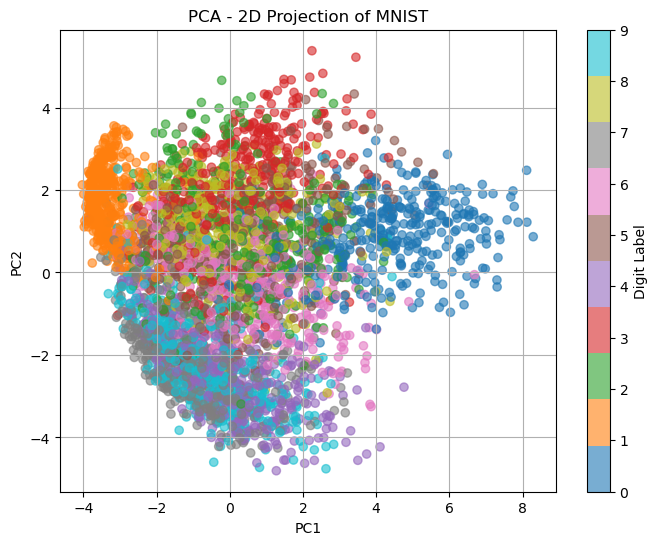

[PCA] MSE Loss (32D reconstruction): 0.016772


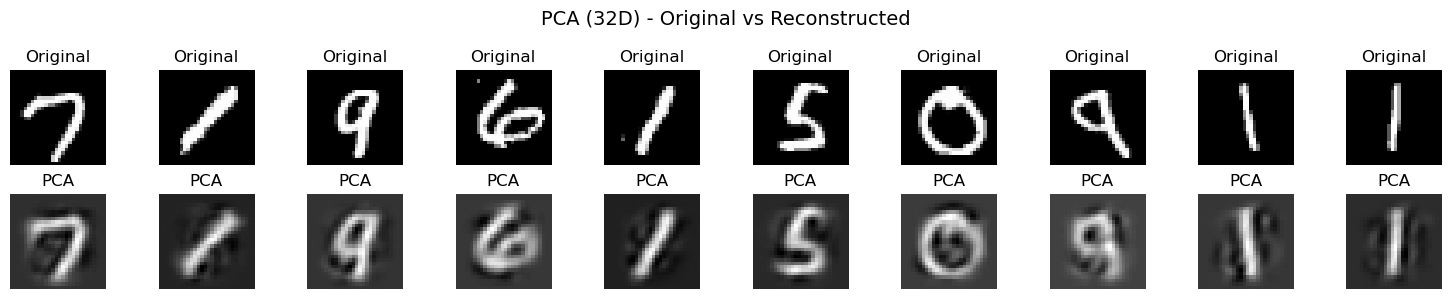

[AE] Epoch 1/20 Loss: 0.171303
[AE] Epoch 2/20 Loss: 0.078591
[AE] Epoch 3/20 Loss: 0.067188
[AE] Epoch 4/20 Loss: 0.062120
[AE] Epoch 5/20 Loss: 0.057313
[AE] Epoch 6/20 Loss: 0.052900
[AE] Epoch 7/20 Loss: 0.048772
[AE] Epoch 8/20 Loss: 0.045369
[AE] Epoch 9/20 Loss: 0.042830
[AE] Epoch 10/20 Loss: 0.040704
[AE] Epoch 11/20 Loss: 0.038838
[AE] Epoch 12/20 Loss: 0.037032
[AE] Epoch 13/20 Loss: 0.035402
[AE] Epoch 14/20 Loss: 0.034055
[AE] Epoch 15/20 Loss: 0.033108
[AE] Epoch 16/20 Loss: 0.032054
[AE] Epoch 17/20 Loss: 0.031143
[AE] Epoch 18/20 Loss: 0.030309
[AE] Epoch 19/20 Loss: 0.029433
[AE] Epoch 20/20 Loss: 0.028607
[AE] MSE Loss (32D reconstruction): 0.028207


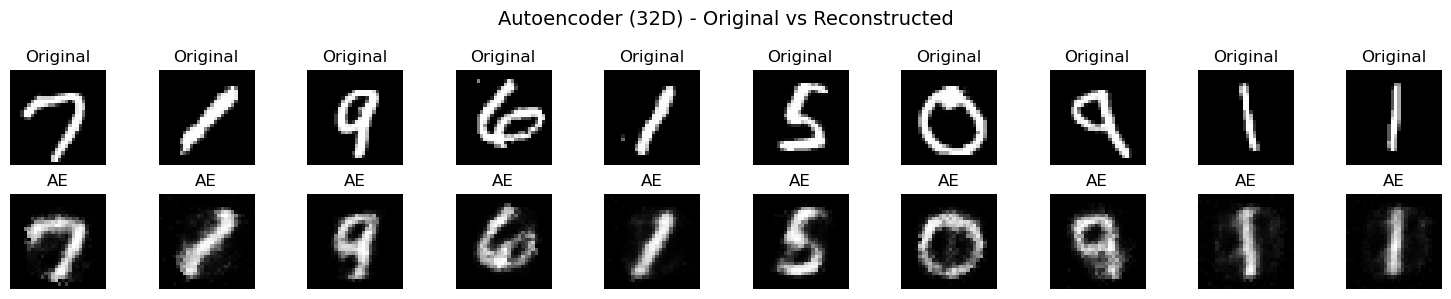


===Performance Comparison (MSE Loss)===
PCA (32D):         0.016772
Autoencoder (32D): 0.028207


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Fetching the  MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data / 255.0
y = mnist.target.astype(int)

# Using a subset
X_train, X_test, y_train, y_test = train_test_split(X[:5000], y[:5000], test_size=0.2, random_state=42)

# PCA - 2D for visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train)

# Plotting the 2D PCA
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Digit Label')
plt.title("PCA - 2D Projection of MNIST")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

#  Reconstruction of PCA - 32D 
pca_32d = PCA(n_components=32)
X_train_32d = pca_32d.fit_transform(X_train)
X_recon_pca = pca_32d.inverse_transform(X_train_32d)

# MSE Loss for PCA
mse_pca = mean_squared_error(X_train, X_recon_pca)
print(f"[PCA] MSE Loss (32D reconstruction): {mse_pca:.6f}")

# Visualizing the Original vs PCA-Reconstructed
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title("Original")

    axes[1, i].imshow(X_recon_pca[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("PCA")

plt.suptitle("PCA (32D) - Original vs Reconstructed", fontsize=14)
plt.tight_layout()
plt.show()

# PyTorch Datasets
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(X_train_tensor, X_train_tensor), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, X_test_tensor), batch_size=128)

# Autoencoder Class
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 32),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Model, loss, optimizer
model = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Train the AE
n_epochs = 20
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for inputs, _ in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[AE] Epoch {epoch+1}/{n_epochs} Loss: {total_loss/len(train_loader):.6f}")

# Reconstruct with AE
model.eval()
with torch.no_grad():
    recon_ae = model(X_train_tensor[:10])

# MSE Loss for AE
with torch.no_grad():
    recon_all = model(X_train_tensor)
    mse_ae = criterion(recon_all, X_train_tensor).item()
print(f"[AE] MSE Loss (32D reconstruction): {mse_ae:.6f}")

# Visualize Original vs AE-Reconstructed
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title("Original")

    axes[1, i].imshow(recon_ae[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("AE")

plt.suptitle("Autoencoder (32D) - Original vs Reconstructed", fontsize=14)
plt.tight_layout()
plt.show()

print("\n===Performance Comparison (MSE Loss)===")
print(f"PCA (32D):         {mse_pca:.6f}")
print(f"Autoencoder (32D): {mse_ae:.6f}")


### Experimented with 30 Epoch 

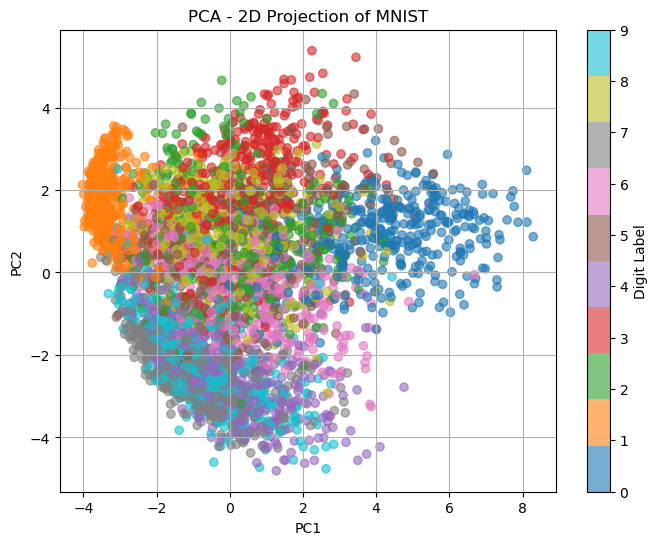

[PCA] MSE Loss (32D reconstruction): 0.016773


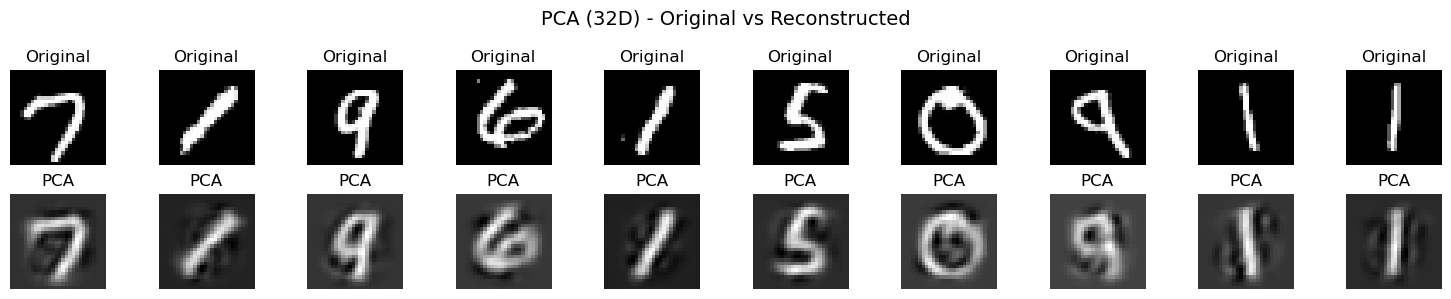

[Deep AE] Epoch 1/30 Loss: 0.103108
[Deep AE] Epoch 2/30 Loss: 0.045518
[Deep AE] Epoch 3/30 Loss: 0.037385
[Deep AE] Epoch 4/30 Loss: 0.032741
[Deep AE] Epoch 5/30 Loss: 0.029561
[Deep AE] Epoch 6/30 Loss: 0.027099
[Deep AE] Epoch 7/30 Loss: 0.025245
[Deep AE] Epoch 8/30 Loss: 0.023507
[Deep AE] Epoch 9/30 Loss: 0.021946
[Deep AE] Epoch 10/30 Loss: 0.020800
[Deep AE] Epoch 11/30 Loss: 0.019820
[Deep AE] Epoch 12/30 Loss: 0.018870
[Deep AE] Epoch 13/30 Loss: 0.018130
[Deep AE] Epoch 14/30 Loss: 0.017540
[Deep AE] Epoch 15/30 Loss: 0.016735
[Deep AE] Epoch 16/30 Loss: 0.016275
[Deep AE] Epoch 17/30 Loss: 0.015739
[Deep AE] Epoch 18/30 Loss: 0.015038
[Deep AE] Epoch 19/30 Loss: 0.014781
[Deep AE] Epoch 20/30 Loss: 0.014346
[Deep AE] Epoch 21/30 Loss: 0.014059
[Deep AE] Epoch 22/30 Loss: 0.013594
[Deep AE] Epoch 23/30 Loss: 0.013242
[Deep AE] Epoch 24/30 Loss: 0.013121
[Deep AE] Epoch 25/30 Loss: 0.012872
[Deep AE] Epoch 26/30 Loss: 0.012654
[Deep AE] Epoch 27/30 Loss: 0.012291
[Deep AE] 

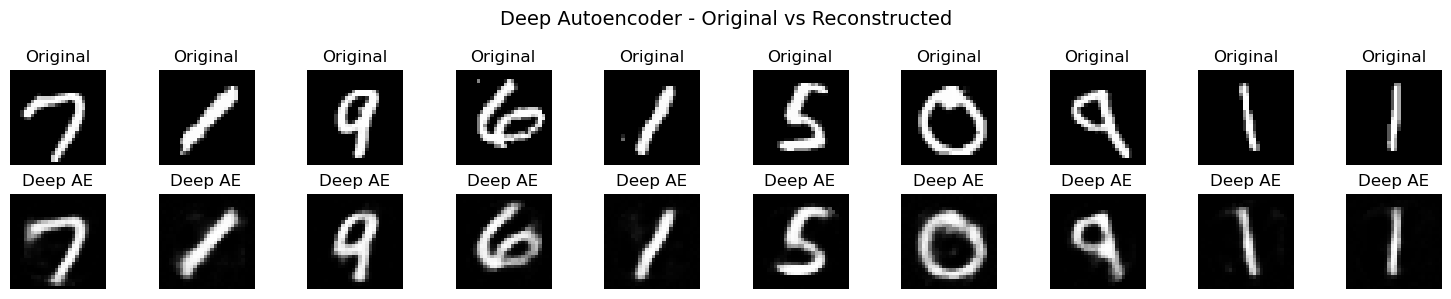


=== Performance Comparison (MSE Loss) ===
PCA (32D):         0.016773
Deep Autoencoder:  0.010472


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

#Fetching the MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data / 255.0
y = mnist.target.astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X[:5000], y[:5000], test_size=0.2, random_state=42)

#  TASK 1: PCA 
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Digit Label')
plt.title("PCA - 2D Projection of MNIST")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

pca_32d = PCA(n_components=32)
X_train_32d = pca_32d.fit_transform(X_train)
X_recon_pca = pca_32d.inverse_transform(X_train_32d)

mse_pca = mean_squared_error(X_train, X_recon_pca)
print(f"[PCA] MSE Loss (32D reconstruction): {mse_pca:.6f}")

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title("Original")

    axes[1, i].imshow(X_recon_pca[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("PCA")
plt.suptitle("PCA (32D) - Original vs Reconstructed", fontsize=14)
plt.tight_layout()
plt.show()

# TASK 2: Deep Autoencoder 
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(X_train_tensor, X_train_tensor), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, X_test_tensor), batch_size=128)

# Deep Autoencoder with 784 -> 256 -> 64 -> 32 -> 64 -> 256 -> 784
class DeepAutoencoder(nn.Module):
    def __init__(self):
        super(DeepAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(),
            nn.Linear(64, 32),
            nn.LeakyReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(),
            nn.Linear(64, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = DeepAutoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Train Deep AE
n_epochs = 30
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for inputs, _ in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[Deep AE] Epoch {epoch+1}/{n_epochs} Loss: {total_loss/len(train_loader):.6f}")

# Reconstruct with AE
model.eval()
with torch.no_grad():
    recon_all = model(X_train_tensor)
    recon_vis = model(X_train_tensor[:10])
    mse_ae = criterion(recon_all, X_train_tensor).item()

print(f"[Deep AE] MSE Loss (32D bottleneck): {mse_ae:.6f}")

# Visualize Original vs AE-Reconstructed
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title("Original")

    axes[1, i].imshow(recon_vis[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("Deep AE")

plt.suptitle("Deep Autoencoder - Original vs Reconstructed", fontsize=14)
plt.tight_layout()
plt.show()

# Final Comparison 
print("\n=== Performance Comparison (MSE Loss) ===")
print(f"PCA (32D):         {mse_pca:.6f}")
print(f"Deep Autoencoder:  {mse_ae:.6f}")


### Task 3


 Training Deep AE with activation: RELU
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
 RELU MSE Loss: 0.020968
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

 RELU Layer Outputs for 1 Sample:
• 256D: (1, 256) → [[2.2544794  0.         3.1585622  0.         0.         0.
  1.9164474  1.086307   1.6873312  0.6233715  3.1883855  1.5051472
  1.0169998  0.         0.         0.         0.08753041 0.
  0.         0.         2.6733475  1.848682   0.         0.
  1.5947489  4.147418   0.         0.         0.         1.3495071
  2.143838   0.         0.         2.050385   0.8998995  1.6516132
  1.2815591  0.         1.5166535  3.0772598  2.2734532  1.987334
  3.076833   3.581064   0.10101248 1.5046198  0.         0.
  0.         2.7575245  5.130052   1.6468421  1.9451928  0.
  2.9608173  2.9673946  4.475279   0.         0.         0.22808628
  0.         1.0494847  0.         1.828306   1.9046248  3.999101
  0.         2.0600142  2.

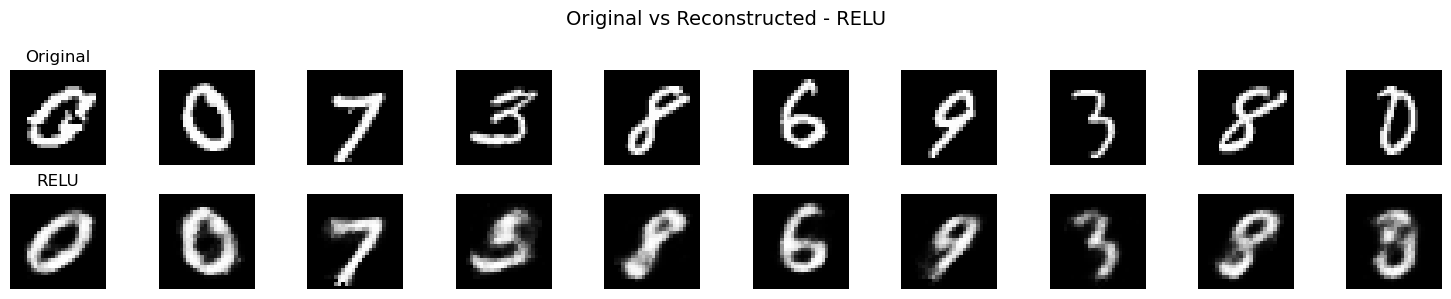


 Training Deep AE with activation: SIGMOID
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
 SIGMOID MSE Loss: 0.060763
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

 SIGMOID Layer Outputs for 1 Sample:
• 256D: (1, 256) → [[0.26945633 0.96780455 0.06041371 0.09004886 0.9424348  0.9465651
  0.2691495  0.9556567  0.15174599 0.8331692  0.09231633 0.20825633
  0.10677265 0.09132101 0.10148621 0.6518748  0.9627958  0.15051542
  0.97707933 0.14740345 0.04593559 0.9744281  0.95161176 0.8920127
  0.9138513  0.13342358 0.98219395 0.04831908 0.9397766  0.14036882
  0.12367689 0.8680388  0.19882981 0.87813926 0.28468713 0.07290871
  0.08565842 0.9787973  0.03748403 0.09020765 0.16985577 0.02594086
  0.12559468 0.8928243  0.14193694 0.02406482 0.9410586  0.95013684
  0.09011672 0.08912631 0.02538418 0.04391669 0.21667299 0.1142035
  0.97260404 0.26507065 0.9455335  0.05670635 0.8701956  0.26126534
  0.13190386 0.9663478  0.3441466  0.2457

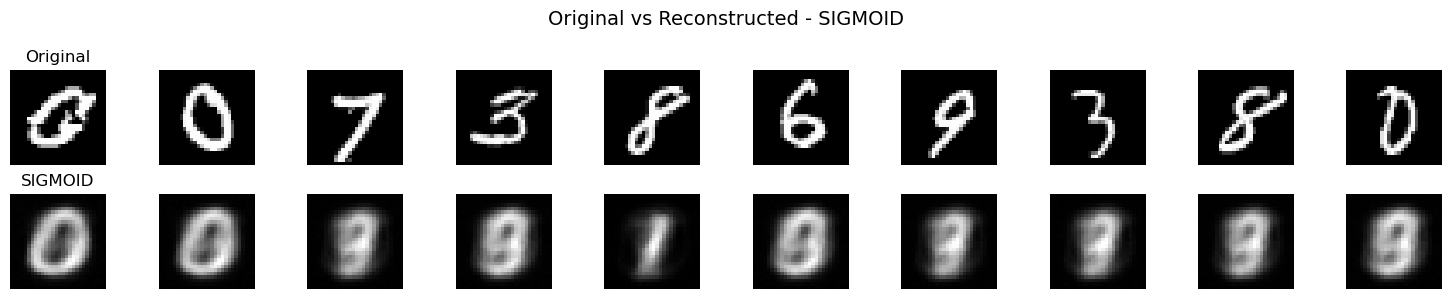


 Training Deep AE with activation: TANH
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
 TANH MSE Loss: 0.028900
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

 TANH Layer Outputs for 1 Sample:
• 256D: (1, 256) → [[ 0.90771616  0.95044935 -0.9949676  -0.01586873 -0.57537985  0.15806459
   0.9740754   0.96865064 -0.99564993 -0.70265055  0.97730947 -0.95641
   0.9756884   0.46417463  0.91292316 -0.9900818  -0.71769696  0.93854713
  -0.99419934 -0.9231197  -0.89835477  0.9916656   0.82043254 -0.60619557
   0.9553731  -0.4099726  -0.6945788   0.9007695  -0.97569513 -0.9011773
  -0.2874149  -0.99832565  0.14998285  0.9903736   0.10700087  0.15809684
   0.999394    0.55609584  0.9285547   0.7524473  -0.21356635  0.279666
   0.7919317   0.895144    0.9999211  -0.99085534  0.9885639  -0.9809605
  -0.01204755  0.7077581   0.5564033  -0.9459507   0.98849654  0.51245725
  -0.8408278  -0.90918845  0.8914745  -0.02342913 -0.19953282  0.432

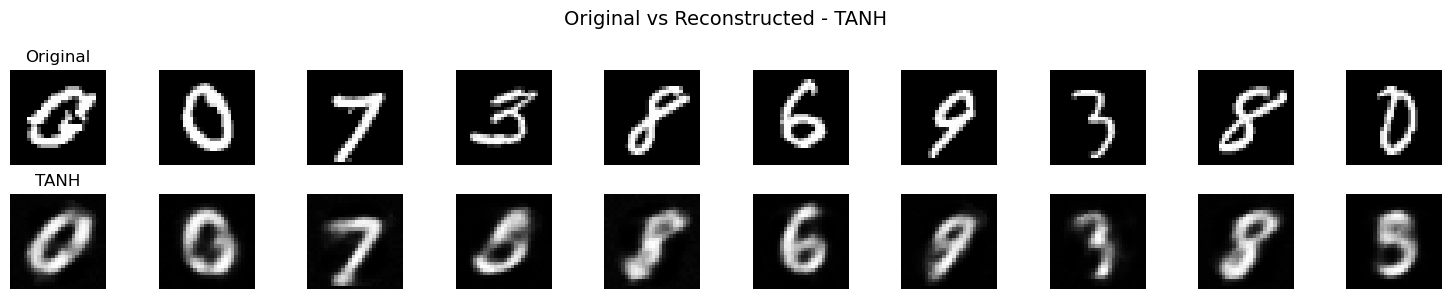


 === Deep Autoencoder MSE Comparison ===
RELU     : MSE = 0.020968
SIGMOID  : MSE = 0.060763
TANH     : MSE = 0.028900


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Fetch MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data.astype('float32') / 255.0
X_train, X_test = train_test_split(X[:5000], test_size=0.2, random_state=42)
input_dim = 784

# Building Deep AE and expose intermediate layers
def build_deep_autoencoder(activation='relu'):
    input_img = Input(shape=(input_dim,), name='input')

    # Encoder
    layer1 = Dense(256, activation=activation, name='enc_256')(input_img)
    layer2 = Dense(64, activation=activation, name='enc_64')(layer1)
    layer3 = Dense(32, activation=activation, name='enc_32')(layer2)

    # Decoder
    layer4 = Dense(64, activation=activation)(layer3)
    layer5 = Dense(256, activation=activation)(layer4)
    output = Dense(784, activation='sigmoid')(layer5)

    # Full model
    autoencoder = Model(inputs=input_img, outputs=output)
    autoencoder.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')

    # Intermediate models
    encoder_256 = Model(inputs=input_img, outputs=layer1)
    encoder_64 = Model(inputs=input_img, outputs=layer2)
    encoder_32 = Model(inputs=input_img, outputs=layer3)

    return autoencoder, encoder_256, encoder_64, encoder_32

# Storing the  results
results = {}

# Looping over activations
for act in ['relu', 'sigmoid', 'tanh']:
    print(f"\n Training Deep AE with activation: {act.upper()}")
    autoencoder, enc256, enc64, enc32 = build_deep_autoencoder(activation=act)
    autoencoder.fit(X_train, X_train, 
                    epochs=20, batch_size=128, 
                    shuffle=True, validation_data=(X_test, X_test), verbose=0)
    
    # Predictions
    recon = autoencoder.predict(X_test)
    mse = mean_squared_error(X_test, recon)
    print(f" {act.upper()} MSE Loss: {mse:.6f}")

    # Intermediate encodings (show for 1 sample)
    sample = X_test[:1]
    out_256 = enc256.predict(sample)
    out_64 = enc64.predict(sample)
    out_32 = enc32.predict(sample)

    print(f"\n {act.upper()} Layer Outputs for 1 Sample:")
    print(f"• 256D: {out_256.shape} → {out_256}")
    print(f"•  64D: {out_64.shape} → {out_64}")
    print(f"•  32D: {out_32.shape} → {out_32}")

    # Visual comparison: Original vs Reconstructed
    plt.figure(figsize=(15, 3))
    for i in range(10):
        ax = plt.subplot(2, 10, i + 1)
        plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
        ax.axis('off')
        if i == 0: ax.set_title("Original")

        ax = plt.subplot(2, 10, i + 1 + 10)
        plt.imshow(recon[i].reshape(28, 28), cmap='gray')
        ax.axis('off')
        if i == 0: ax.set_title(f"{act.upper()}")

    plt.suptitle(f"Original vs Reconstructed - {act.upper()}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Store results
    results[act] = {
        'mse': mse,
        'recon': recon,
        'encoder_outputs': {
            '256D': out_256,
            '64D': out_64,
            '32D': out_32
        }
    }

# Summary comparison
print("\n === Deep Autoencoder MSE Comparison ===")
for act, data in results.items():
    print(f"{act.upper():<8} : MSE = {data['mse']:.6f}")
